In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import numpy as np
from matplotlib import pyplot as plt
from functools import partial
from scipy.optimize import fmin
import torch
import os, glob

from indentation.indentationset import IndentationSet
from indentation.processing.find_contact import findContact_minimum, findContact_blackMagic, findContact_blackMagic_CNN
from indentation.processing.signal import do_nothing, crop_start, crop_end, crop_afm_temp
from indentation.processing.calculate_parameters import parameter_youngs_modulus
from indentation.processing.plotting import plot_curve_parameters_bar, plot_instance_parameters_bar, plot_mean_force_curves
from indentation.ml.models import ConvClassifier_1, ConvClassifier_2

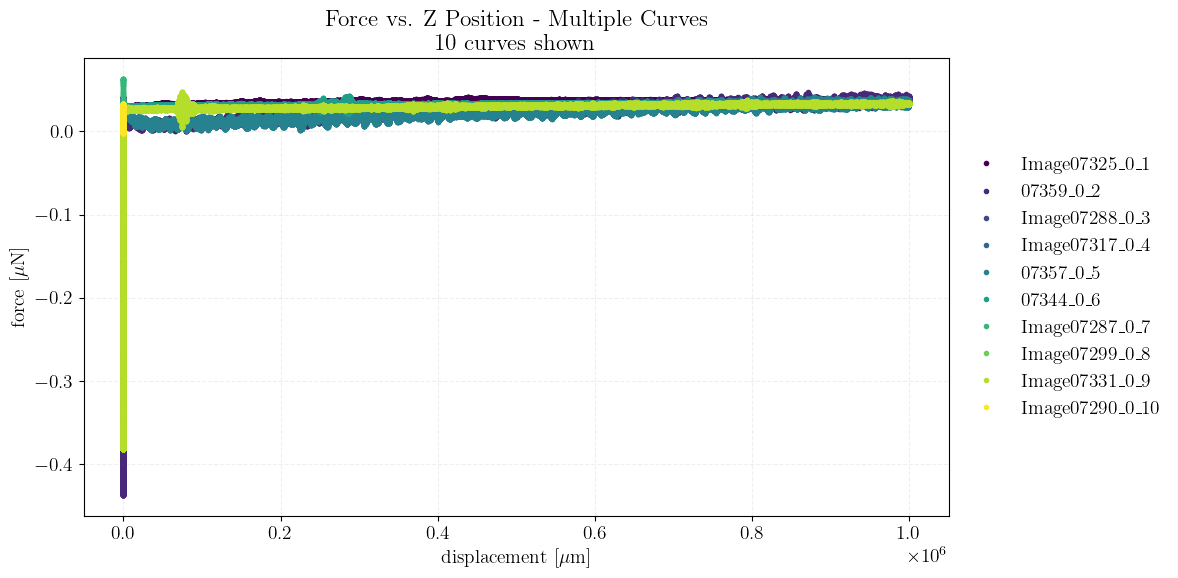

In [11]:
#paths = glob.glob(r"R:\Group\File_Exchange\Raoul_Paula\immersed_pdms_35t1_afm_081124\*.txt")
paths = glob.glob(r"F:\pcameron\3_Experimental\Edoardo Mazza - Havar\2024-07-31\fluidfm\specs FLUIDFM\*.txt")

afm = IndentationSet(paths[10:20], exp_type="fluidfm")

afm.plot_all_raw(linestyle="")

#processing_pl = [crop, findContact_minimum]
processing_pl = [crop_afm_temp]

afm.process_raw(processing_pl)

#afm.plot_all()

#afm.plot_all_raw()

# plt.figure()
# plt.plot(afm.data[0]["processed"]["force"])
#plt.plot(afm.data[0]["raw"]["force"])

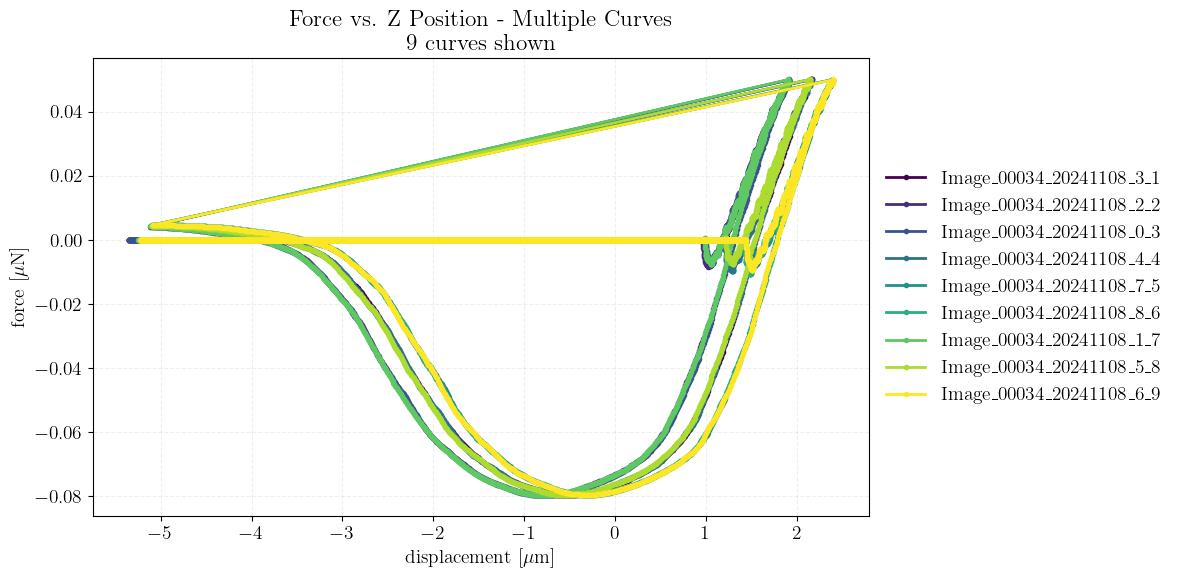

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Force vs. Z Position - Multiple Curves\n9 curves shown'}, xlabel='displacement [$\\mu$m]', ylabel='force [$\\mu$N]'>)

In [12]:
afm.plot_all_raw()

Text(0.5, 1.0, 'AFM indentation (R = 5 um) of PDMS 30:1')

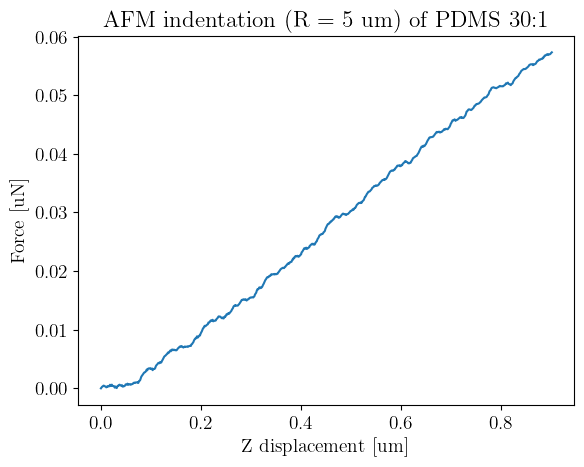

In [13]:
force = afm.data[0]["processed"]["force"] #/ 1e6
disp = -afm.data[0]["processed"]["z"] #/ 1e6
cutoff = 10
R = 5e-6

plt.plot(disp, force)
plt.ylabel("Force [uN]")
plt.xlabel("Z displacement [um]")
plt.title("AFM indentation (R = 5 um) of PDMS 30:1")

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 20
         Function evaluations: 59
[1000.]


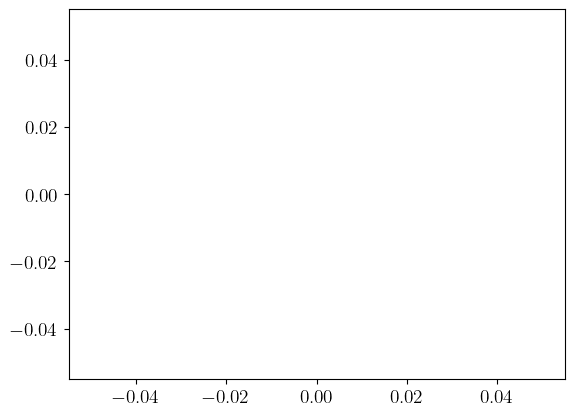

In [14]:
def hertzian_force(E, z, R):
    nu = 0.5
    F = 4.0/3.0 * E / (1-nu*nu) * np.sqrt(R) * z ** 1.5
    return F

def residuals(E, z, force, cutoff, R):
    i_max = np.where(z > cutoff / 100.0 * R)[0][0]
    force = force[0:i_max]
    z = z[0:i_max]
    
    F_hertz = hertzian_force(E, z, R)
    
    y = np.sum((force - F_hertz) ** 2)

    return y

optim_E = fmin(residuals, 1000, args=(disp, force, cutoff, R))
print(optim_E)



i_max = np.where(disp > cutoff / 100.0 * R)[0][0]
force = force[0:i_max]
disp = disp[0:i_max]
F_hertz = hertzian_force(optim_E, disp, R)

plt.figure()
plt.plot(disp, F_hertz, 'r-')
plt.plot(disp, force)
plt.show()

Mean and std: 23.127740756894703 1.035441108535675


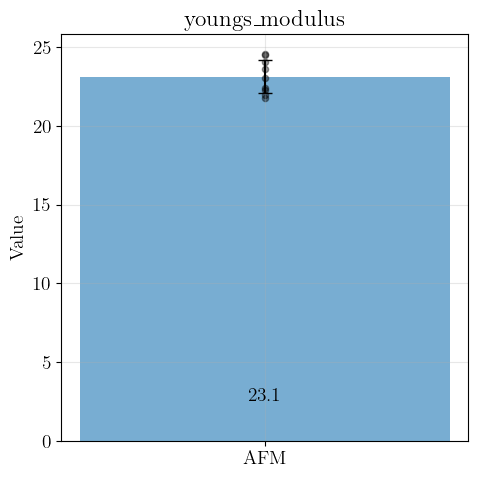

In [15]:
function_arguments = dict(radius=5, nu=0.5, cutoff=10, keyname="youngs_modulus")
afm.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)
plot_curve_parameters_bar(afm,
                         parameter_names=['youngs_modulus'],
                         labels=['AFM'],
                         figsize=(5,5))

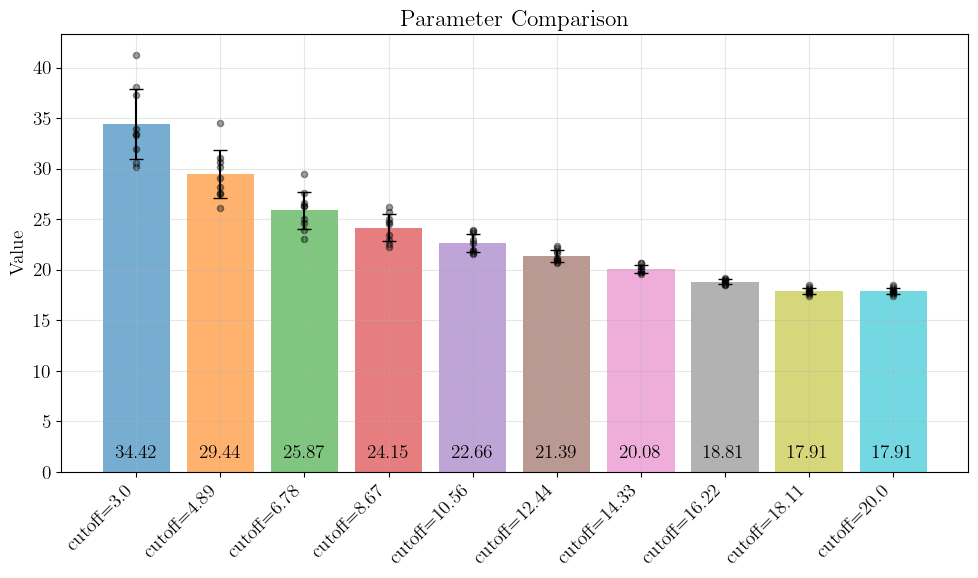

In [16]:
cutoffs = np.linspace(3, 20, 10)

for cutoff in cutoffs:
    function_arguments = dict(radius=5, nu=0.5, cutoff=cutoff, keyname="cutoff="+str(np.round(cutoff, 2)))
    afm.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)

plot_instance_parameters_bar(afm,
                         parameter_names=[*["cutoff="+str(np.round(cutoff, 2)) for cutoff in cutoffs]],
                         figsize=(10,6))